# Carbon Emission Dataset - Exploratory Data Analysis (EDA)

**Course:** Advanced Python Project  
**Dataset:** Carbon emission dataset with Industry  

This notebook covers:

1. Load and inspect data
2. Data cleaning
3. Exploratory data analysis
4. Bivariate and multivariate analysis
5. Time series exploration
6. Advanced analytical questions

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

## 1. Load and Inspect Data

In [2]:
DATA_PATH = r"carbon_emission_dataset_with_Industry (3).csv"

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    df = pd.read_csv(r"/mnt/data/carbon_emission_dataset_with_Industry (3).csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (18250, 22)


,Company_ID,Date,Sector,Total_Energy_Consumption_kWh,Renewable_Energy_Consumption_kWh,NonRenewable_Energy_Consumption_kWh,Production_Output_Units,Supply_Chain_Transport_km,Supply_Chain_Transport_Mode,Raw_Material_Usage_kg,Carbon_Emission_tCO2e_TARGET,Energy_Cost_USD,Carbon_Tax_USD,Process_Efficiency_Percent,Employment_Count,Public_Acceptance_Index,Carbon_Reduction_Strategy,Strategy_Implementation_Cost_USD,Expected_Carbon_Reduction_Percent,Expected_Renewable_Share_Percent,Social_Impact_Score,Industry_Sectors
0,C001,2024-01-01,Manufacturing,53751.61,12766.80,40984.81,3008.90,3814.12,Truck,51334.48,12.5560,3040.12,338.76,81.07,2128,0.77,Process Reengineering,188176.25,16.79,40.89,0.40,Steel Manufacturing
1,C001,2024-01-02,Manufacturing,170872.89,76733.84,94139.05,4062.25,1199.66,Air,17154.72,35.3949,12837.43,1073.13,69.26,855,0.77,Efficiency Upgrade,489246.31,12.57,58.19,0.86,Cement Production
2,C001,2024-01-03,Manufacturing,142777.96,75794.17,66983.79,6196.17,3670.57,Truck,56288.43,30.4517,16985.65,1390.41,90.33,3613,0.48,Carbon Tax Compliance,165061.64,12.11,68.14,0.79,Automotive Industry
3,C001,2024-01-04,Manufacturing,152532.15,20698.80,131833.35,6714.80,2903.63,Ship,21438.17,49.5550,18192.00,1942.56,79.49,3156,0.85,Efficiency Upgrade,191619.23,5.64,23.30,0.55,Logistics
4,C001,2024-01-05,Manufacturing,81647.43,46657.82,34989.61,8887.31,1916.05,Rail,37694.23,16.8968,6704.86,472.20,68.63,4915,0.47,Process Reengineering,459129.15,12.99,65.44,0.95,Steel Manufacturing


In [3]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Company_ID', 'Date', 'Sector', 'Total_Energy_Consumption_kWh', 'Renewable_Energy_Consumption_kWh', 'NonRenewable_Energy_Consumption_kWh', 'Production_Output_Units', 'Supply_Chain_Transport_km', 'Supply_Chain_Transport_Mode', 'Raw_Material_Usage_kg', 'Carbon_Emission_tCO2e_TARGET', 'Energy_Cost_USD', 'Carbon_Tax_USD', 'Process_Efficiency_Percent', 'Employment_Count', 'Public_Acceptance_Index', 'Carbon_Reduction_Strategy', 'Strategy_Implementation_Cost_USD', 'Expected_Carbon_Reduction_Percent', 'Expected_Renewable_Share_Percent', 'Social_Impact_Score', 'Industry_Sectors']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 22 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Company_ID                           18250 non-null  object 
 1   Date                                 18250 non-null  object 
 2   Sector                               18250 non-null  object 
 3   Total_Energy_Consumption_kWh         18250 non-null  float64
 4   Renewable_Energy_Consumption_kWh     18250 non-null  float64
 5   NonRenewable_Energy_Consumption_kWh  18250 non-null  float64
 6   Production_Output_Units              18250 non-null  float64
 7   Supply_Chain_Transport_km            18250 non-null  float64
 8   Supply_Chain_Transport_Mode          18250 non-null  object 
 9   Raw_Material_Usage_kg                18250 non-null  float64
 10  Carbon_Emission_tCO2e_TARGET         18250 non-null  float64
 11  Energy_Cost_USD             

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company_ID,18250,50,C001,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,18250,365,2024-01-01,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sector,18250,5,Manufacturing,5110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Energy_Consumption_kWh,18250.0,NaN,NaN,NaN,124776.987158,43106.624251,50008.73,87326.365,124728.53,162042.955,199988.91
Renewable_Energy_Consumption_kWh,18250.0,NaN,NaN,NaN,43759.097184,24291.666951,5041.2,24455.5025,38888.005,59545.025,119005.26
NonRenewable_Energy_Consumption_kWh,18250.0,NaN,NaN,NaN,81017.889975,33957.852247,20483.26,53738.5475,77007.82,104085.3725,179431.02
Production_Output_Units,18250.0,NaN,NaN,NaN,5538.963915,2597.576117,1000.47,3273.995,5556.4,7802.095,9999.78
Supply_Chain_Transport_km,18250.0,NaN,NaN,NaN,2734.813587,1300.146027,500.38,1609.1225,2735.02,3862.7175,4999.89
Supply_Chain_Transport_Mode,18250,4,Ship,4581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Raw_Material_Usage_kg,18250.0,NaN,NaN,NaN,44869.415215,20110.509566,10006.5,27439.335,44803.63,62291.0275,79994.46


## 2. Data Cleaning

The cleaning step checks missing values, duplicates, and converts the date column to datetime format.

In [6]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percent.round(2)
})
missing_table

,Missing Values,Missing Percentage
Company_ID,0,0.0
Date,0,0.0
Sector,0,0.0
Total_Energy_Consumption_kWh,0,0.0
Renewable_Energy_Consumption_kWh,0,0.0
NonRenewable_Energy_Consumption_kWh,0,0.0
Production_Output_Units,0,0.0
Supply_Chain_Transport_km,0,0.0
Supply_Chain_Transport_Mode,0,0.0
Raw_Material_Usage_kg,0,0.0


In [7]:
print("Number of duplicated rows before cleaning:", df.duplicated().sum())

df_clean = df.copy()
df_clean = df_clean.drop_duplicates()

if 'Date' in df_clean.columns:
    df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df_clean.select_dtypes(include=['object']).columns

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Number of duplicated rows after cleaning:", df_clean.duplicated().sum())
print("Total missing values after cleaning:", df_clean.isnull().sum().sum())
df_clean.dtypes

Number of duplicated rows before cleaning: 0
Number of duplicated rows after cleaning: 0
Total missing values after cleaning: 0


Company_ID                                     object
Date                                   datetime64[ns]
Sector                                         object
Total_Energy_Consumption_kWh                  float64
Renewable_Energy_Consumption_kWh              float64
NonRenewable_Energy_Consumption_kWh           float64
Production_Output_Units                       float64
Supply_Chain_Transport_km                     float64
Supply_Chain_Transport_Mode                    object
Raw_Material_Usage_kg                         float64
Carbon_Emission_tCO2e_TARGET                  float64
Energy_Cost_USD                               float64
Carbon_Tax_USD                                float64
Process_Efficiency_Percent                    float64
Employment_Count                                int64
Public_Acceptance_Index                       float64
Carbon_Reduction_Strategy                      object
Strategy_Implementation_Cost_USD              float64
Expected_Carbon_Reduction_Pe

## 3. Exploratory Analysis

The following features are required in the project description:

- Total_Energy_Consumption_kWh
- Renewable_Energy_Consumption_kWh
- NonRenewable_Energy_Consumption_kWh
- Production_Output_Units
- Supply_Chain_Transport_km

In [8]:
main_features = [
    'Total_Energy_Consumption_kWh',
    'Renewable_Energy_Consumption_kWh',
    'NonRenewable_Energy_Consumption_kWh',
    'Production_Output_Units',
    'Supply_Chain_Transport_km'
]

target_col = 'Carbon_Emission_tCO2e_TARGET'

basic_stats = df_clean[main_features].agg(['mean', 'median', 'max', 'min']).T
basic_stats

,mean,median,max,min
Total_Energy_Consumption_kWh,124776.987158,124728.530,199988.91,50008.73
Renewable_Energy_Consumption_kWh,43759.097184,38888.005,119005.26,5041.20
NonRenewable_Energy_Consumption_kWh,81017.889975,77007.820,179431.02,20483.26
Production_Output_Units,5538.963915,5556.400,9999.78,1000.47
Supply_Chain_Transport_km,2734.813587,2735.020,4999.89,500.38


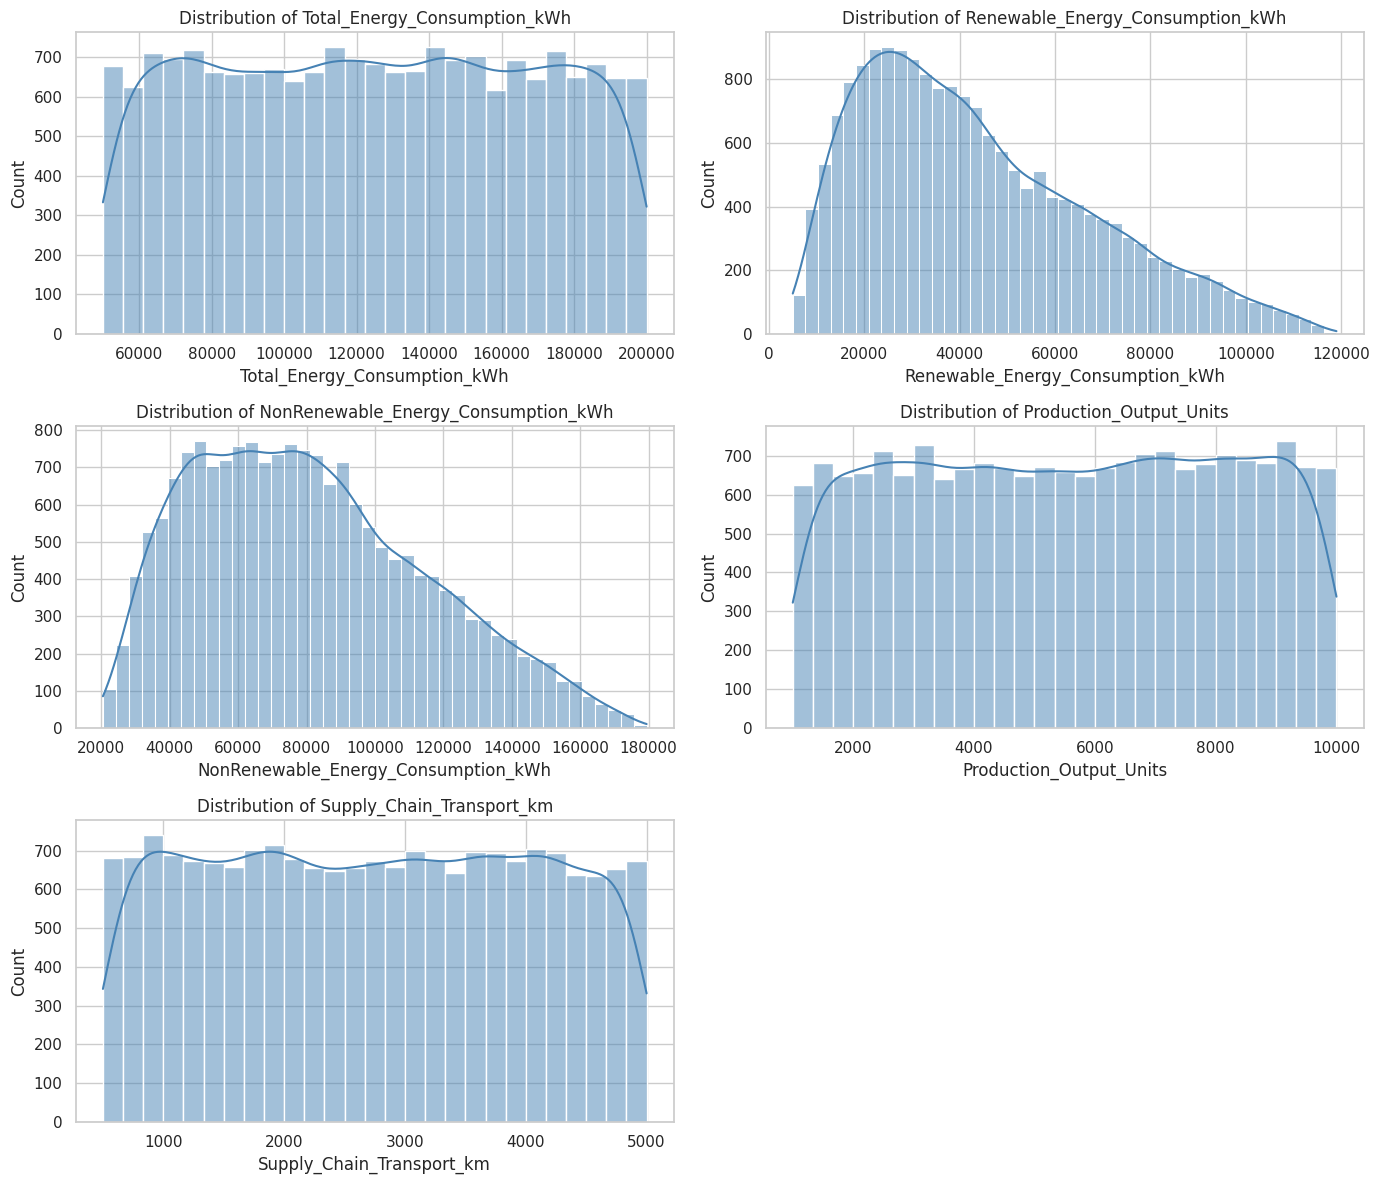

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(main_features):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

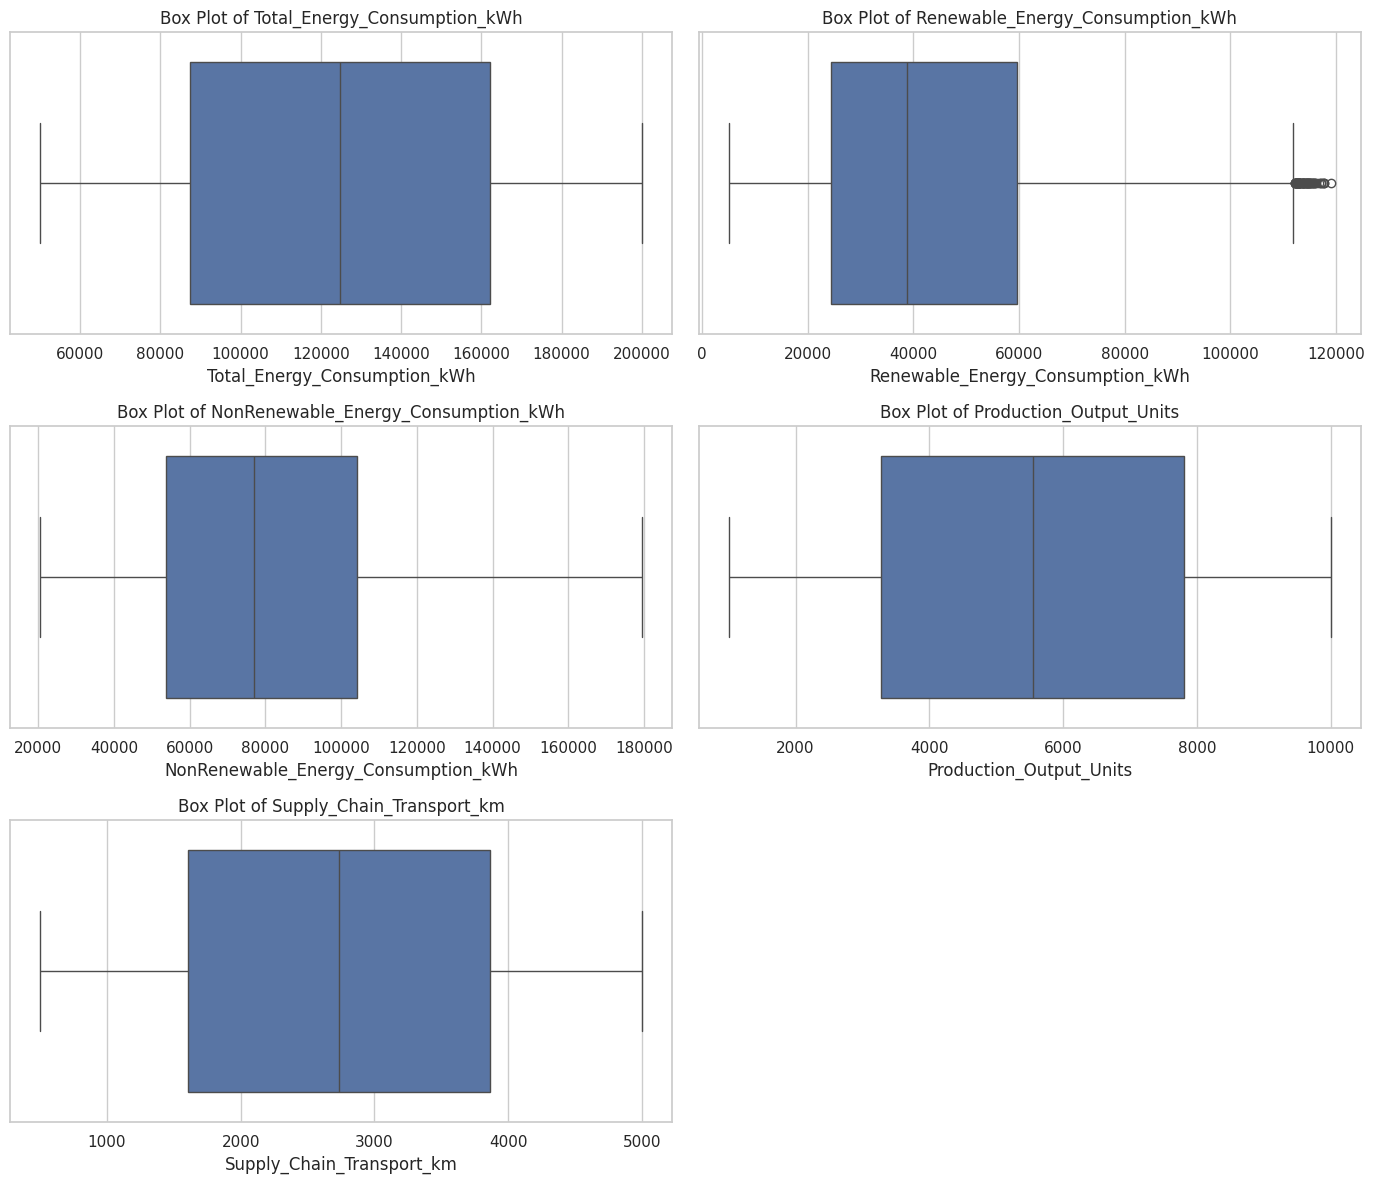

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(main_features):
    sns.boxplot(x=df_clean[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

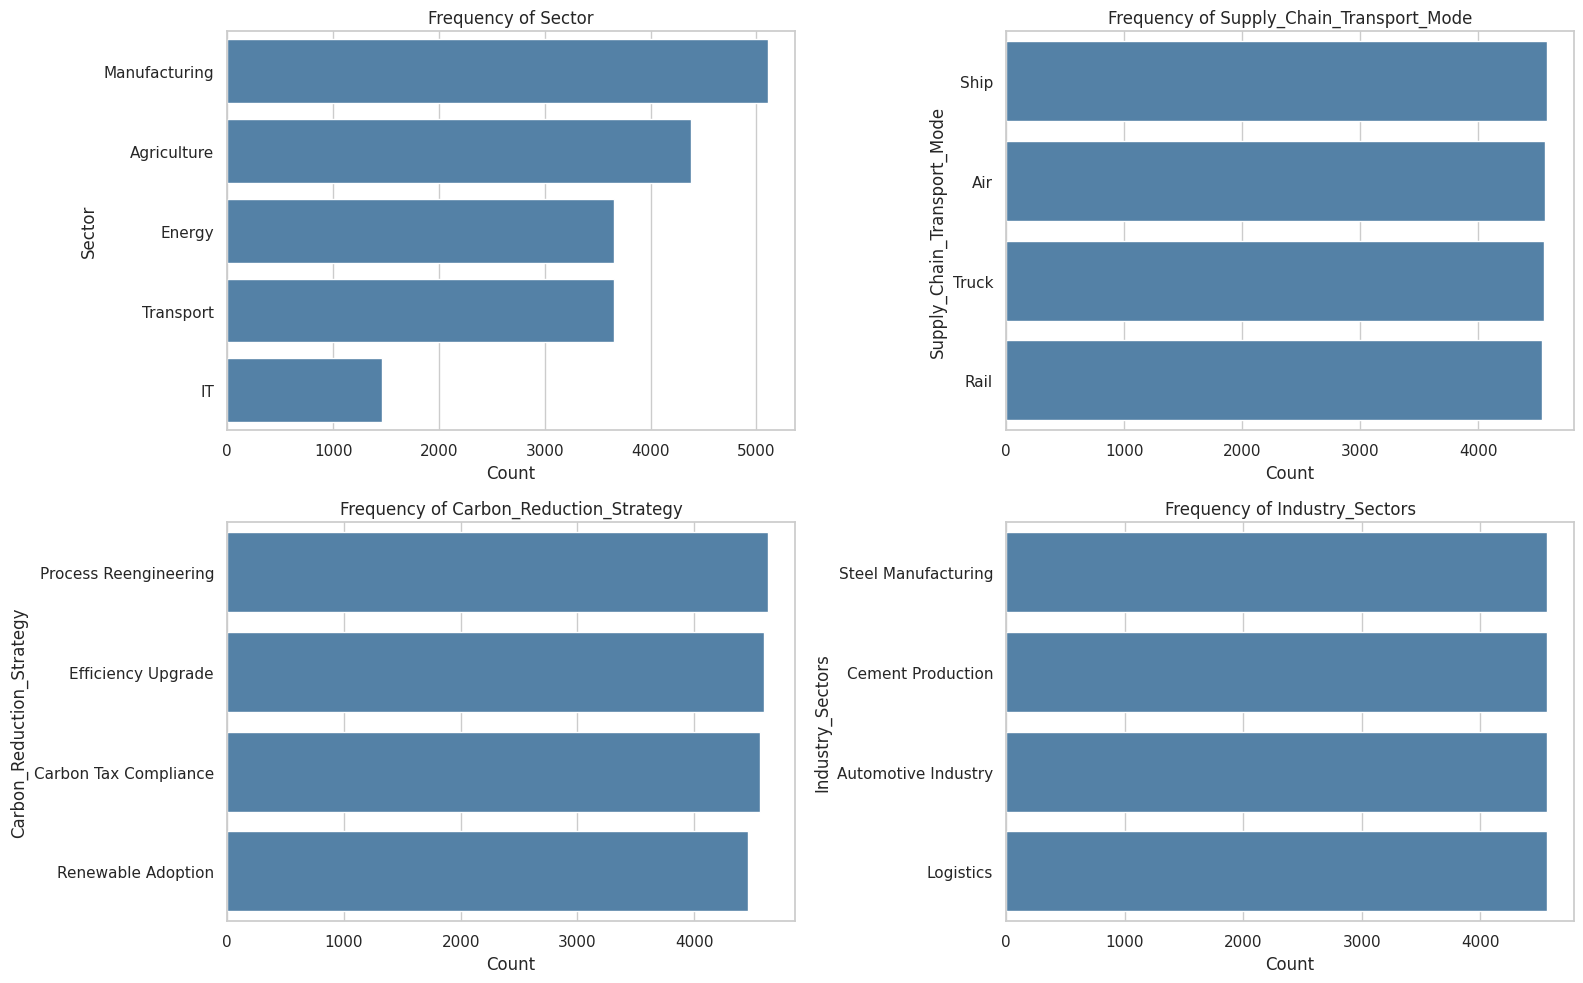

In [11]:
categorical_cols = ['Sector', 'Supply_Chain_Transport_Mode', 'Carbon_Reduction_Strategy', 'Industry_Sectors']
existing_categorical = [col for col in categorical_cols if col in df_clean.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(existing_categorical):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, y=col, order=order, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Frequency of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(col)

for j in range(len(existing_categorical), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

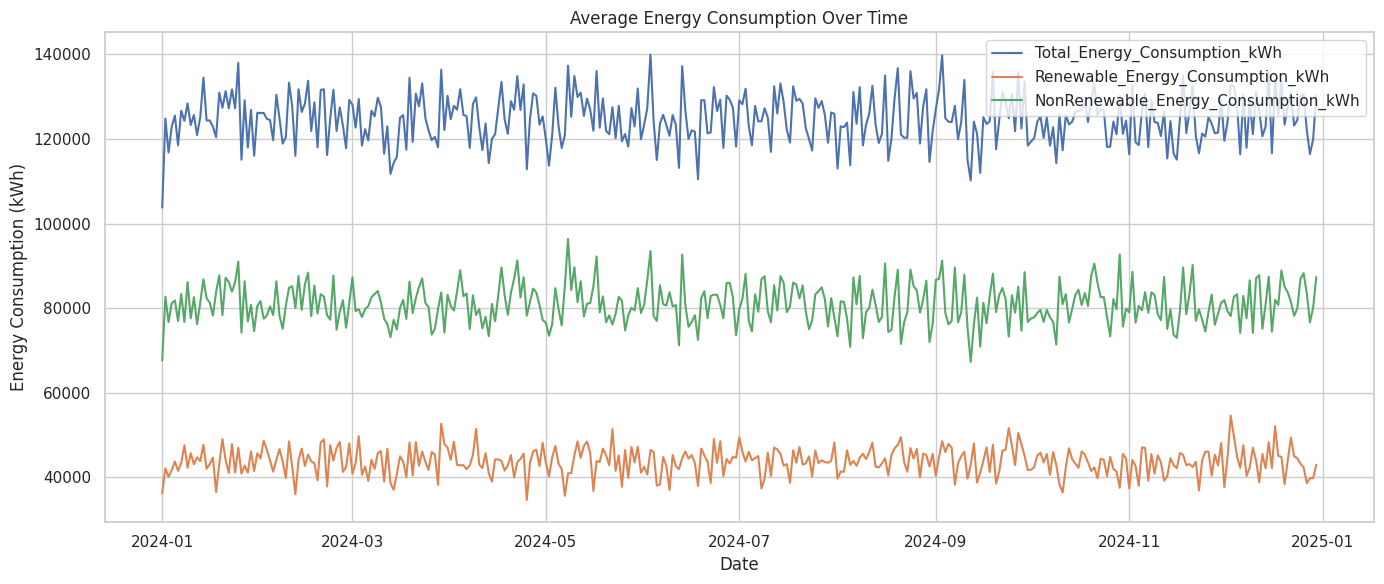

In [12]:
daily_energy = df_clean.groupby('Date')[[
    'Total_Energy_Consumption_kWh',
    'Renewable_Energy_Consumption_kWh',
    'NonRenewable_Energy_Consumption_kWh'
]].mean()

plt.figure(figsize=(14, 6))
for col in daily_energy.columns:
    plt.plot(daily_energy.index, daily_energy[col], label=col)

plt.title('Average Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
temperature_cols = [col for col in df_clean.columns if 'temp' in col.lower()]

if len(temperature_cols) > 0:
    temp_col = temperature_cols[0]
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_clean, x=temp_col, y=target_col, alpha=0.5)
    plt.title(f'Emissions vs {temp_col}')
    plt.tight_layout()
    plt.show()
else:
    print('No temperature column was found in this dataset, so emissions vs temperature cannot be plotted.')

No temperature column was found in this dataset, so emissions vs temperature cannot be plotted.


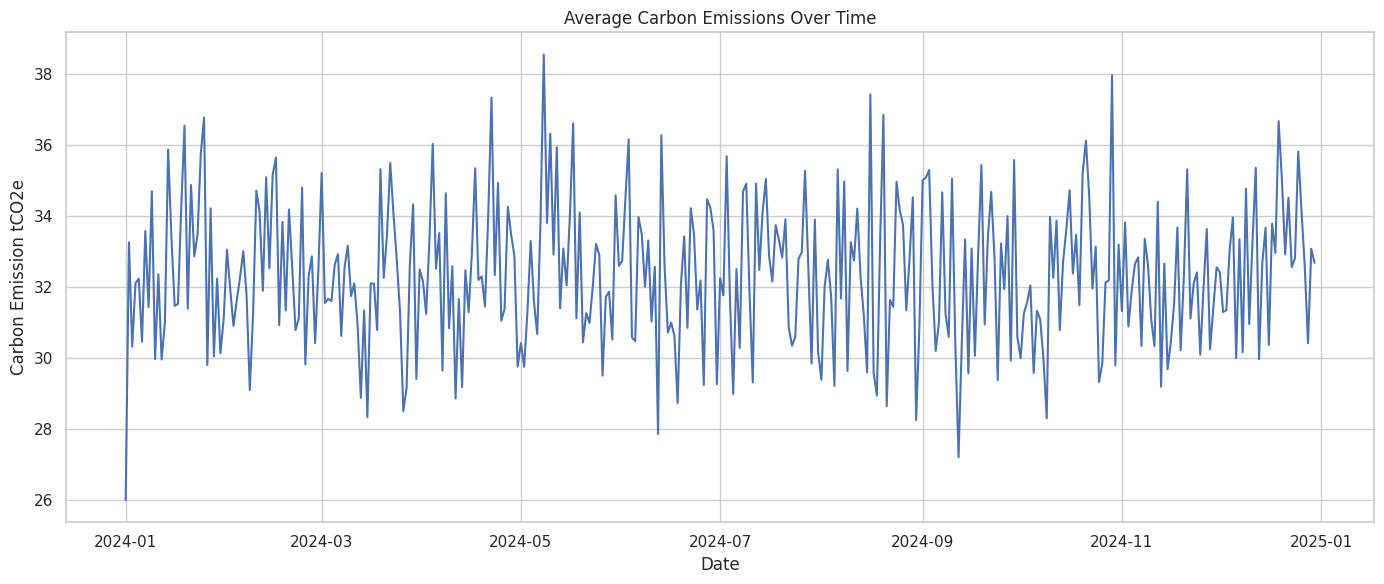

In [14]:
daily_emissions = df_clean.groupby('Date')[target_col].mean()

plt.figure(figsize=(14, 6))
plt.plot(daily_emissions.index, daily_emissions.values)
plt.title('Average Carbon Emissions Over Time')
plt.xlabel('Date')
plt.ylabel('Carbon Emission tCO2e')
plt.tight_layout()
plt.show()

## 4. Bivariate and Multivariate Analysis

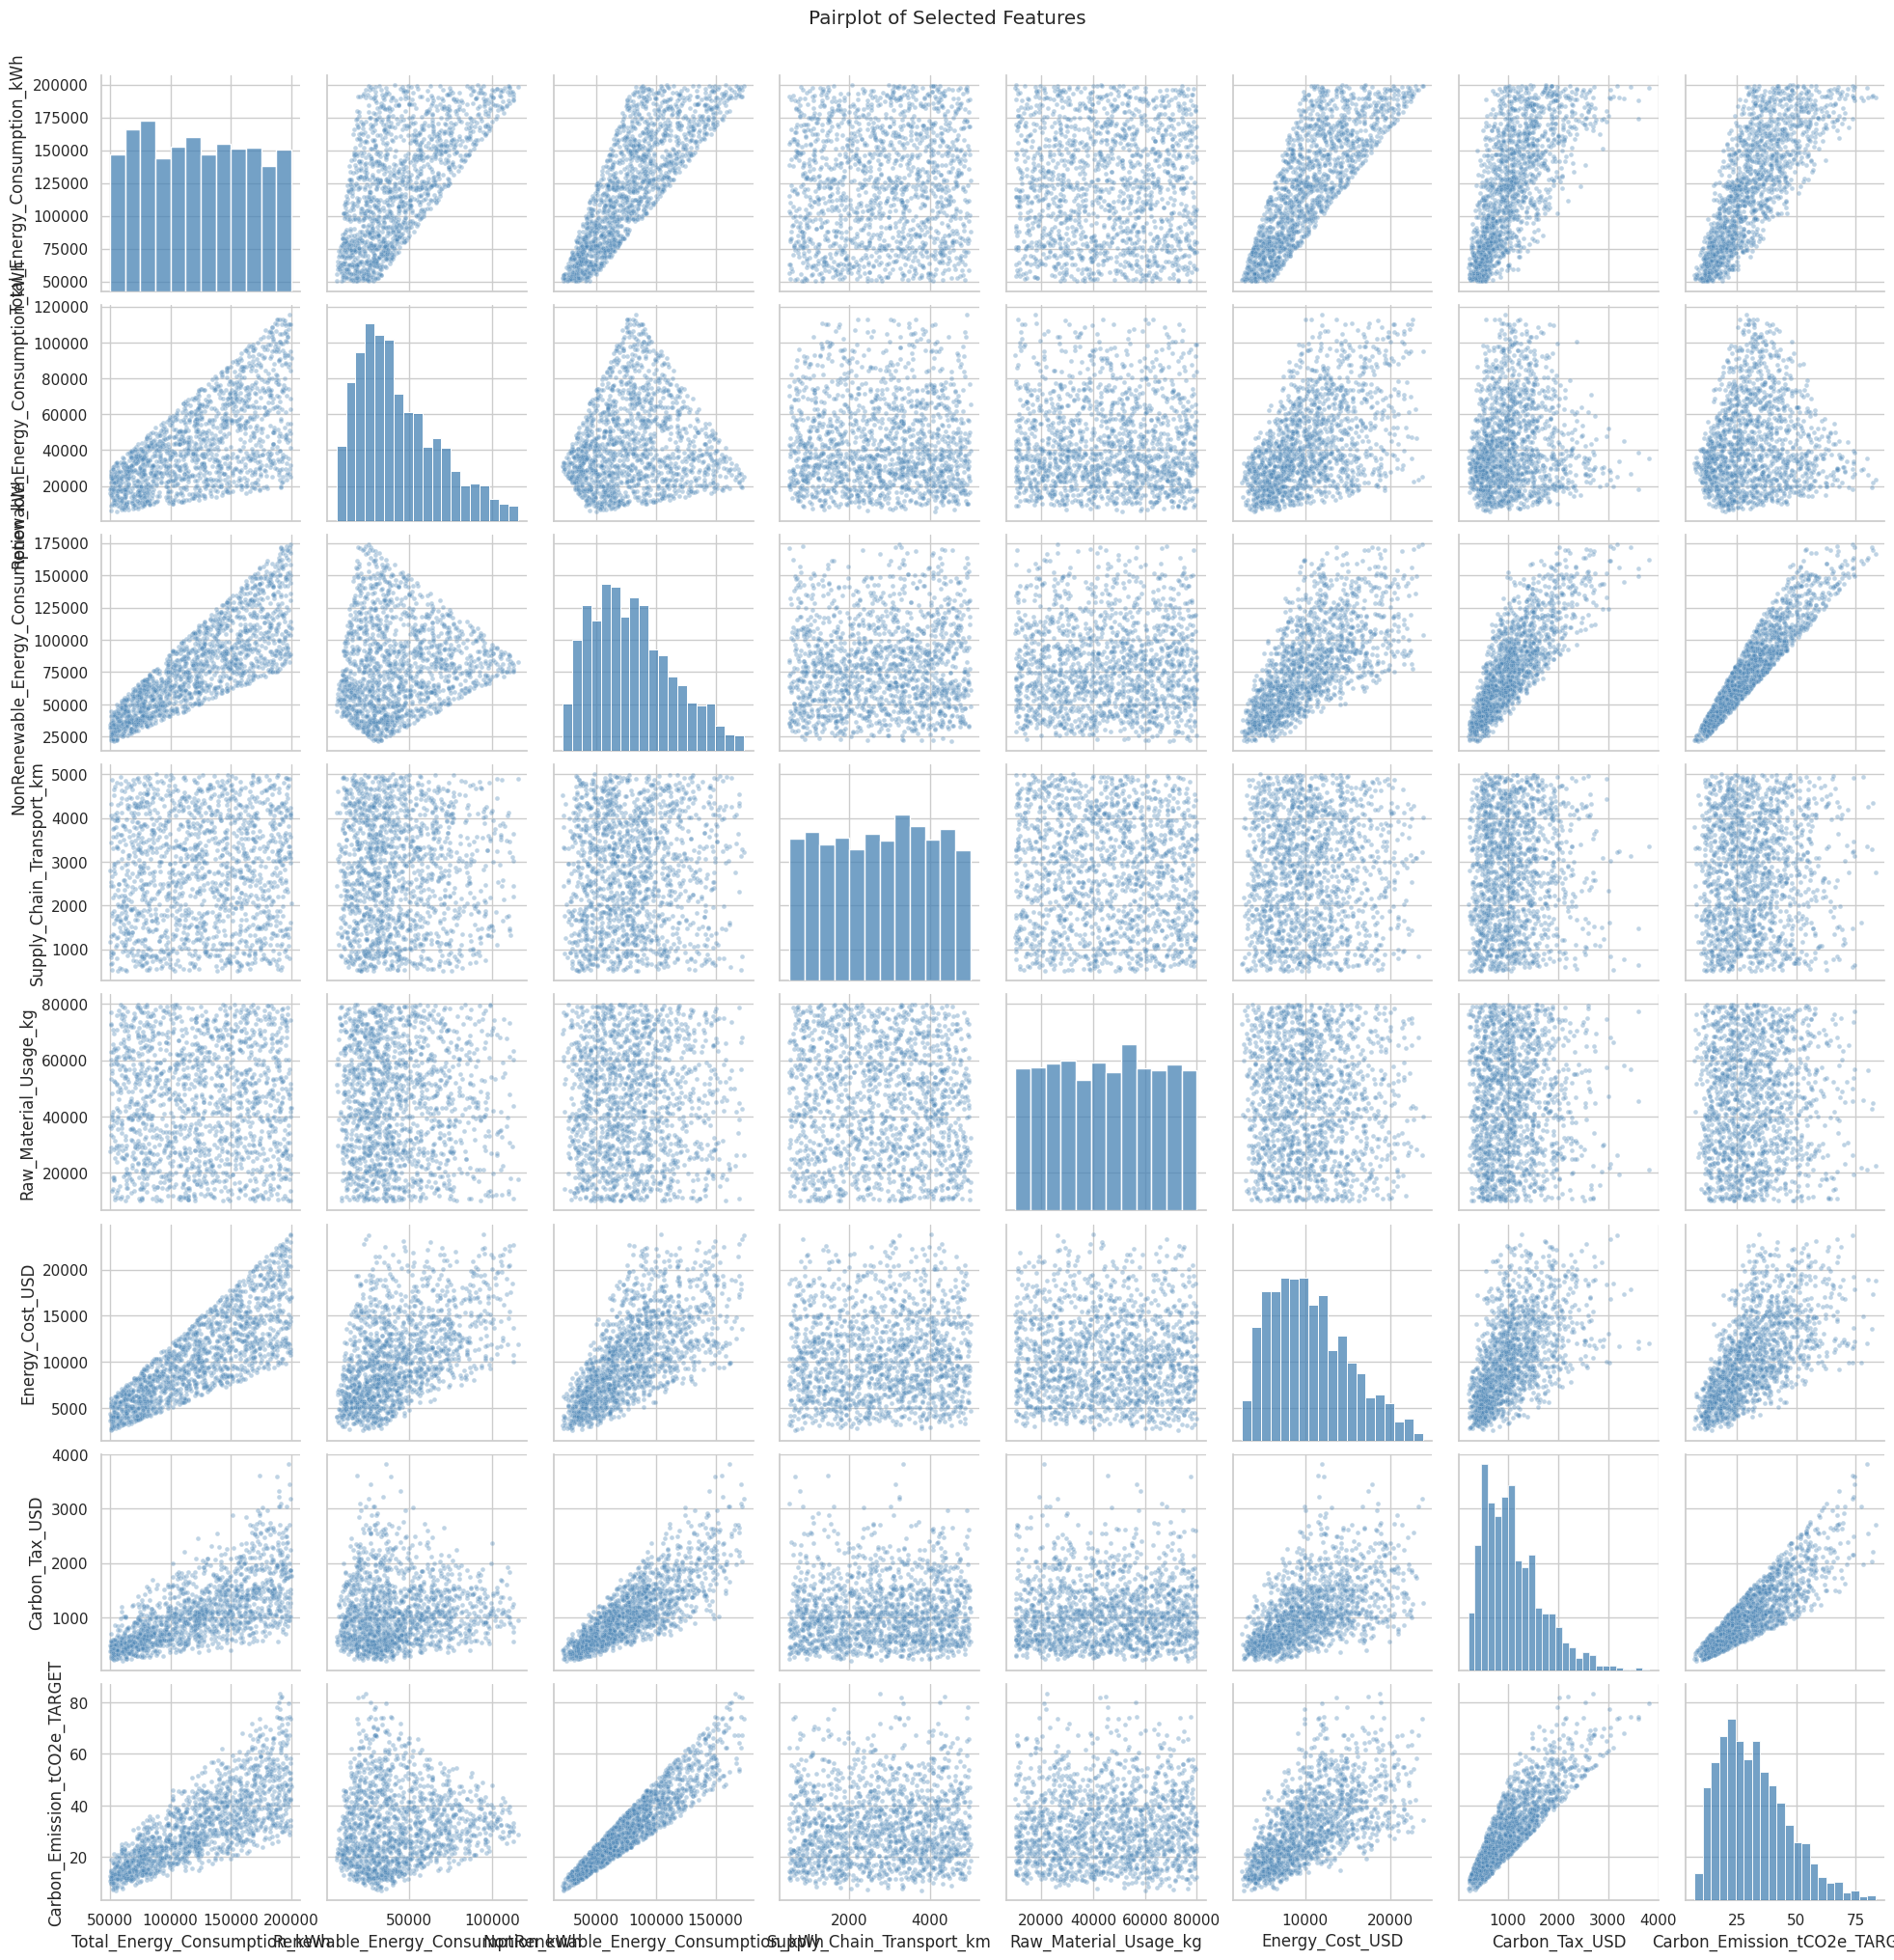

In [15]:
emission_related_features = [
    'Total_Energy_Consumption_kWh',
    'Renewable_Energy_Consumption_kWh',
    'NonRenewable_Energy_Consumption_kWh',
    'Supply_Chain_Transport_km',
    'Raw_Material_Usage_kg',
    'Energy_Cost_USD',
    'Carbon_Tax_USD',
    target_col
]

existing_emission_features = [col for col in emission_related_features if col in df_clean.columns]

sns.pairplot(df_clean[existing_emission_features].sample(min(1500, len(df_clean)), random_state=42), diag_kind='hist', diag_kws={'color': 'steelblue'}, plot_kws={'color': 'steelblue', 'alpha': 0.35, 's': 12})
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

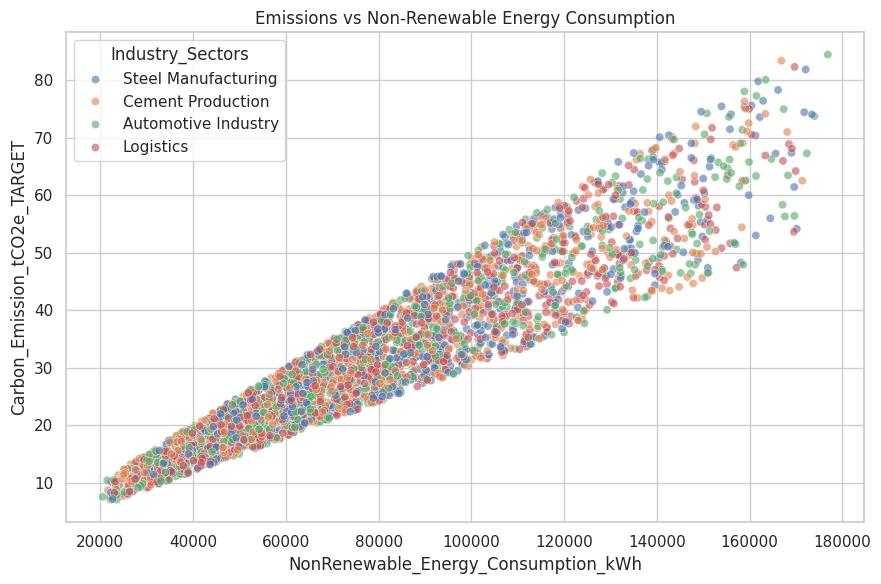

In [16]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_clean.sample(min(3000, len(df_clean)), random_state=42),
    x='NonRenewable_Energy_Consumption_kWh',
    y=target_col,
    hue='Industry_Sectors' if 'Industry_Sectors' in df_clean.columns else None,
    alpha=0.6
)
plt.title('Emissions vs Non-Renewable Energy Consumption')
plt.tight_layout()
plt.show()

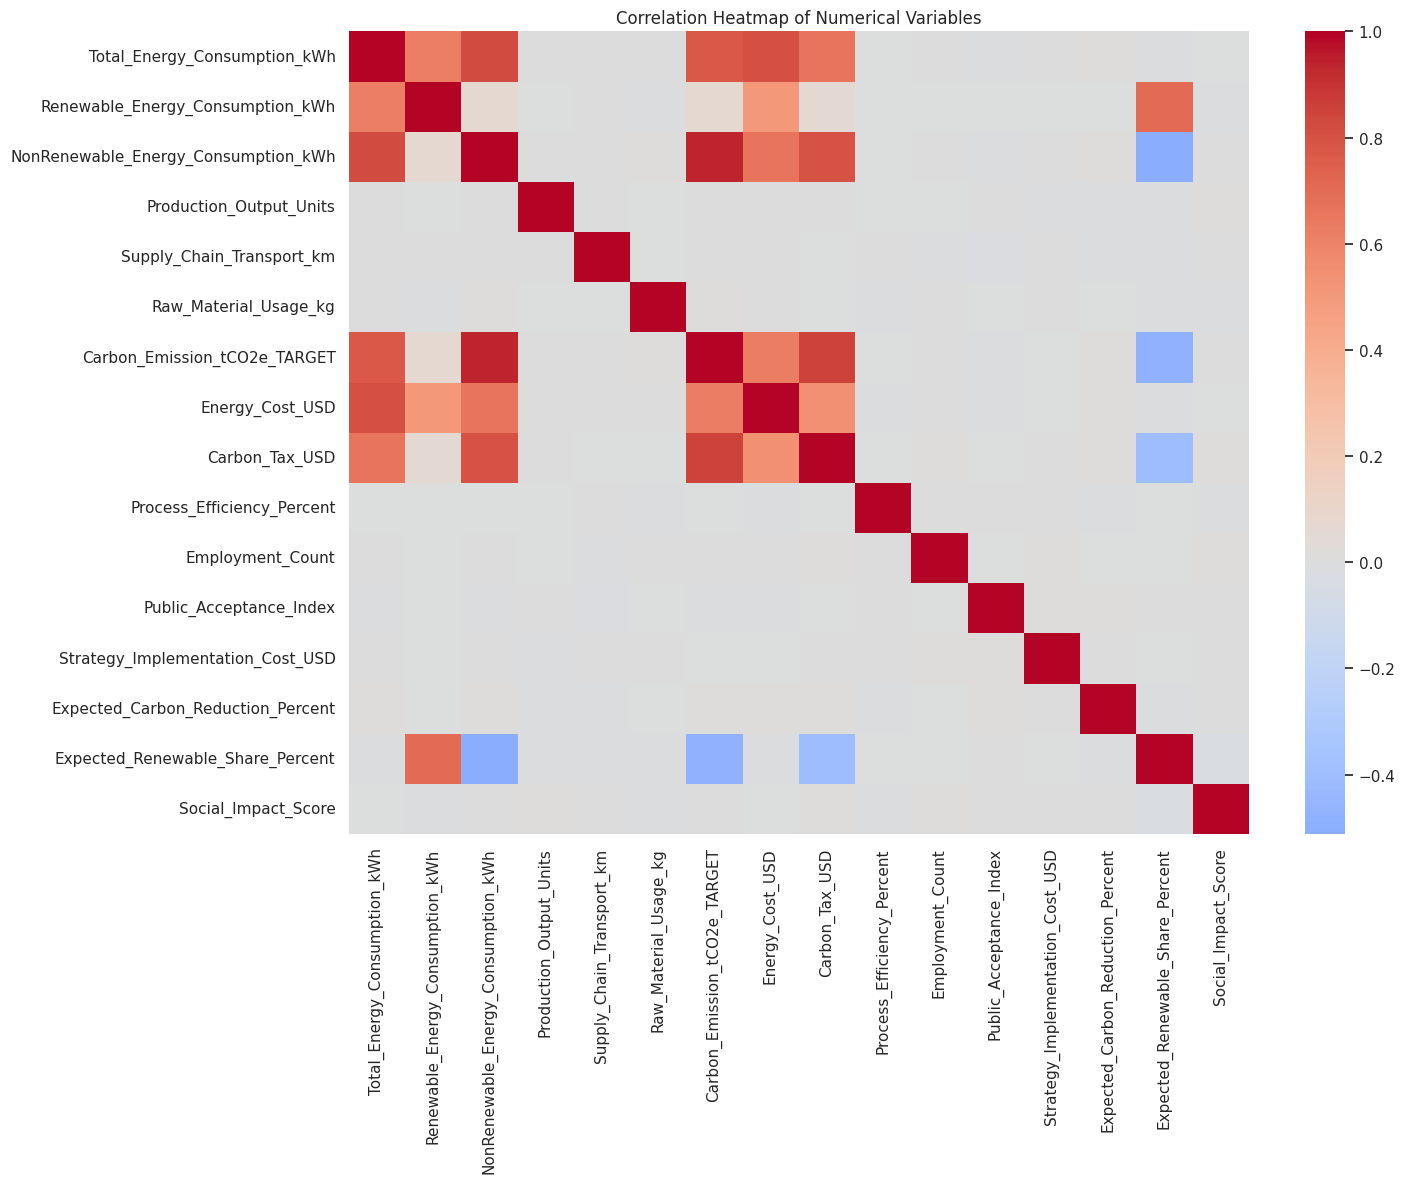

In [17]:
numeric_df = df_clean.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

In [18]:
correlation_with_target = corr_matrix[target_col].sort_values(key=lambda x: x.abs(), ascending=False)
correlation_with_target

Carbon_Emission_tCO2e_TARGET           1.000000
NonRenewable_Energy_Consumption_kWh    0.937198
Carbon_Tax_USD                         0.855654
Total_Energy_Consumption_kWh           0.777758
Energy_Cost_USD                        0.626154
Expected_Renewable_Share_Percent      -0.476811
Renewable_Energy_Consumption_kWh       0.070036
Expected_Carbon_Reduction_Percent      0.010295
Raw_Material_Usage_kg                  0.009820
Social_Impact_Score                    0.007216
Production_Output_Units                0.006059
Public_Acceptance_Index               -0.005967
Employment_Count                       0.004777
Supply_Chain_Transport_km              0.004581
Process_Efficiency_Percent            -0.003971
Strategy_Implementation_Cost_USD       0.001160
Name: Carbon_Emission_tCO2e_TARGET, dtype: float64

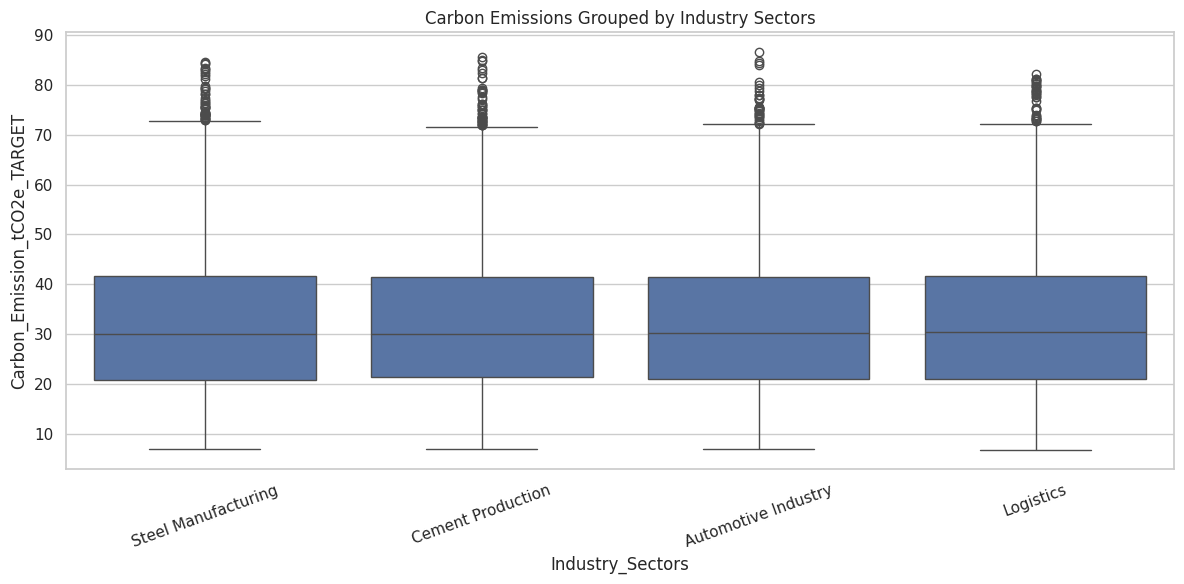

In [19]:
if 'Industry_Sectors' in df_clean.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_clean, x='Industry_Sectors', y=target_col)
    plt.title('Carbon Emissions Grouped by Industry Sectors')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [20]:
group_columns = [col for col in ['Sector', 'Industry_Sectors', 'Supply_Chain_Transport_Mode', 'Carbon_Reduction_Strategy'] if col in df_clean.columns]

for col in group_columns:
    display(df_clean.groupby(col)[target_col].agg(['count', 'mean', 'median', 'min', 'max']).sort_values('mean', ascending=False))

,count,mean,median,min,max
Sector,,,,,
IT,1460,32.495888,30.50760,7.1531,85.6785
Manufacturing,5110,32.450112,30.29085,6.9443,84.4110
Agriculture,4380,32.410406,30.29810,7.6380,83.3355
Transport,3650,32.337938,29.88715,6.8149,84.9779
Energy,3650,32.166558,29.90545,7.5518,86.5718


,count,mean,median,min,max
Industry_Sectors,,,,,
Automotive Industry,4562,32.404282,30.3037,6.9029,86.5718
Cement Production,4563,32.361200,30.0197,7.0306,85.6785
Logistics,4562,32.353115,30.3466,6.8149,82.2790
Steel Manufacturing,4563,32.341804,29.9812,6.9448,84.6155


,count,mean,median,min,max
Supply_Chain_Transport_Mode,,,,,
Air,4567,32.573525,30.4602,7.0457,84.6155
Truck,4559,32.406441,29.9204,6.9443,84.7752
Rail,4543,32.268548,30.1406,6.8149,86.5718
Ship,4581,32.211916,30.1231,6.9448,85.6785


,count,mean,median,min,max
Carbon_Reduction_Strategy,,,,,
Efficiency Upgrade,4594,32.531888,30.30245,7.6291,85.6785
Process Reengineering,4632,32.371044,30.15455,6.9029,84.8606
Carbon Tax Compliance,4567,32.296504,30.36220,7.0306,86.5718
Renewable Adoption,4457,32.257292,29.95840,6.8149,84.4110


## 5. Time Series Exploration

In [21]:
daily = df_clean.groupby('Date').agg({
    target_col: 'mean',
    'Total_Energy_Consumption_kWh': 'mean',
    'Renewable_Energy_Consumption_kWh': 'mean',
    'NonRenewable_Energy_Consumption_kWh': 'mean'
}).sort_index()

daily.head()

,Carbon_Emission_tCO2e_TARGET,Total_Energy_Consumption_kWh,Renewable_Energy_Consumption_kWh,NonRenewable_Energy_Consumption_kWh
Date,,,,
2024-01-01,26.009626,103777.9366,36173.7922,67604.1444
2024-01-02,33.267676,124834.2430,42111.0506,82723.1924
2024-01-03,30.327104,116817.8570,40096.3884,76721.4686
2024-01-04,32.113988,122871.4012,41708.9032,81162.4980
2024-01-05,32.245070,125542.1864,43720.9086,81821.2778


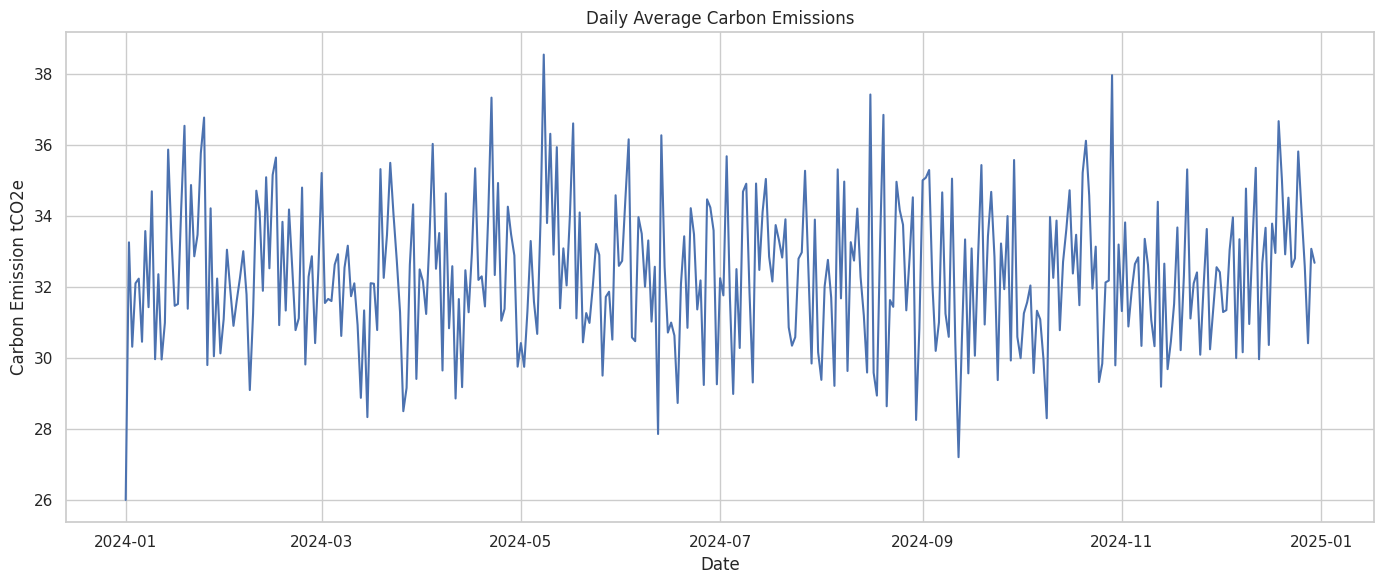

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(daily.index, daily[target_col])
plt.title('Daily Average Carbon Emissions')
plt.xlabel('Date')
plt.ylabel('Carbon Emission tCO2e')
plt.tight_layout()
plt.show()

In [23]:
if len(temperature_cols) > 0:
    temp_col = temperature_cols[0]
    daily_temp = df_clean.groupby('Date')[temp_col].mean()
    plt.figure(figsize=(14, 6))
    plt.plot(daily_temp.index, daily_temp.values)
    plt.title(f'{temp_col} Trend Over Time')
    plt.xlabel('Date')
    plt.ylabel(temp_col)
    plt.tight_layout()
    plt.show()
else:
    print('No temperature column was found, so temperature trend over time is not available.')

No temperature column was found, so temperature trend over time is not available.


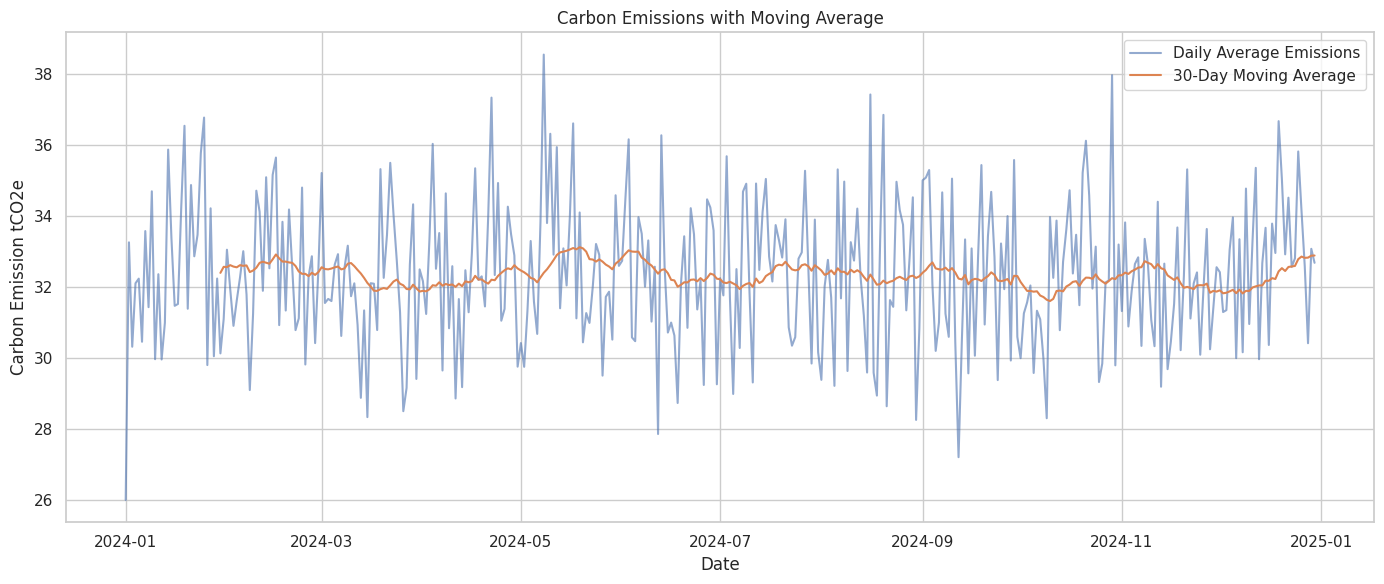

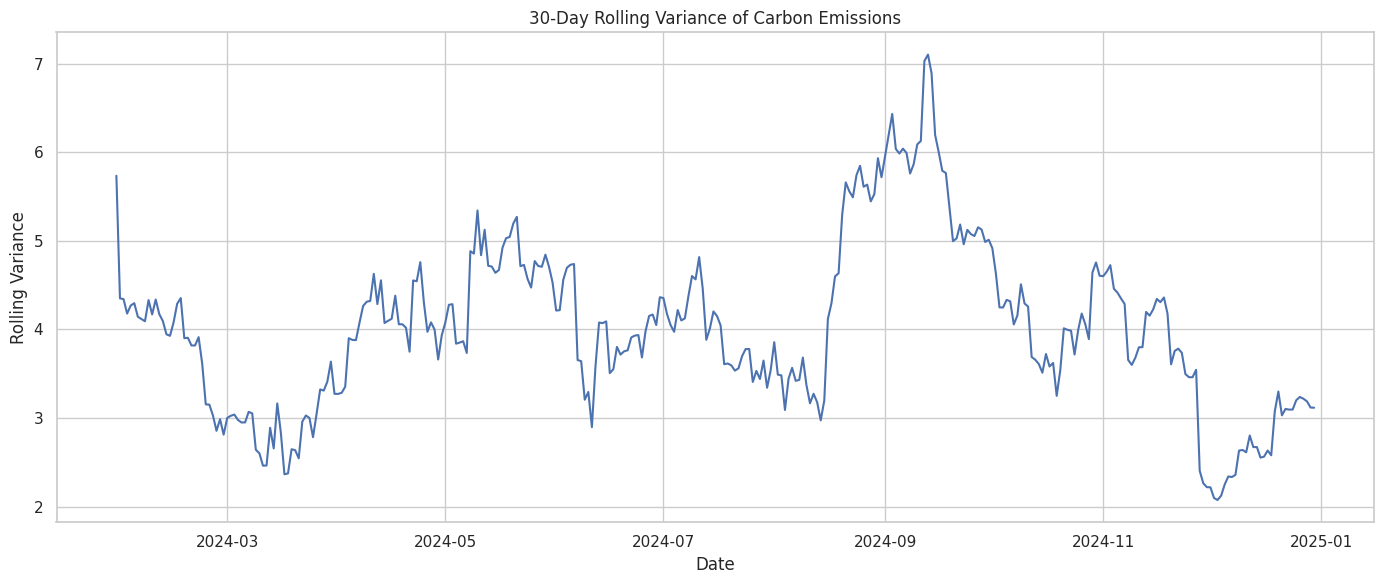

In [24]:
rolling_window = 30

daily['Moving_Average_30_Days'] = daily[target_col].rolling(window=rolling_window).mean()
daily['Rolling_Variance_30_Days'] = daily[target_col].rolling(window=rolling_window).var()

plt.figure(figsize=(14, 6))
plt.plot(daily.index, daily[target_col], label='Daily Average Emissions', alpha=0.6)
plt.plot(daily.index, daily['Moving_Average_30_Days'], label='30-Day Moving Average')
plt.title('Carbon Emissions with Moving Average')
plt.xlabel('Date')
plt.ylabel('Carbon Emission tCO2e')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(daily.index, daily['Rolling_Variance_30_Days'])
plt.title('30-Day Rolling Variance of Carbon Emissions')
plt.xlabel('Date')
plt.ylabel('Rolling Variance')
plt.tight_layout()
plt.show()

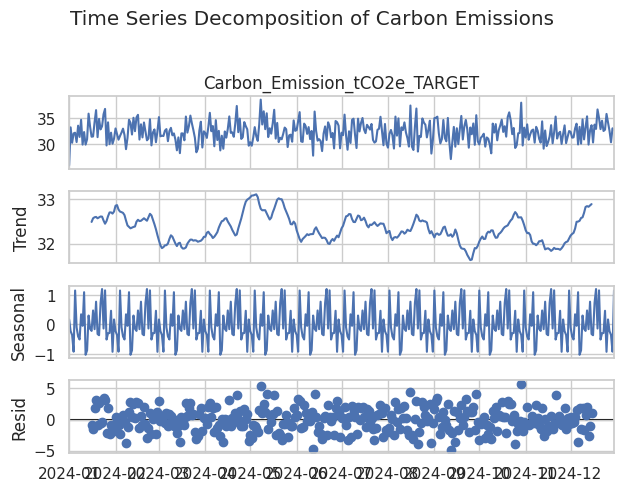

In [25]:
series = daily[target_col].dropna()

if len(series) >= 60:
    decomposition = seasonal_decompose(series, model='additive', period=30)
    decomposition.plot()
    plt.suptitle('Time Series Decomposition of Carbon Emissions', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough data points for time series decomposition.')

## 6. Advanced Analytical Questions

In [26]:
source_cols = [
    'Total_Energy_Consumption_kWh',
    'Renewable_Energy_Consumption_kWh',
    'NonRenewable_Energy_Consumption_kWh',
    'Supply_Chain_Transport_km',
    'Raw_Material_Usage_kg',
    'Energy_Cost_USD',
    'Carbon_Tax_USD'
]
source_cols = [col for col in source_cols if col in df_clean.columns]

variability = pd.DataFrame({
    'Standard Deviation': df_clean[source_cols].std(),
    'Coefficient of Variation': df_clean[source_cols].std() / df_clean[source_cols].mean()
}).sort_values('Coefficient of Variation', ascending=False)

variability

,Standard Deviation,Coefficient of Variation
Renewable_Energy_Consumption_kWh,24291.666951,0.555123
Carbon_Tax_USD,590.407029,0.522696
Supply_Chain_Transport_km,1300.146027,0.475406
Raw_Material_Usage_kg,20110.509566,0.448201
Energy_Cost_USD,4532.900551,0.427593
NonRenewable_Energy_Consumption_kWh,33957.852247,0.419140
Total_Energy_Consumption_kWh,43106.624251,0.345469


Skewness: 0.6664
Kurtosis: -0.0037
Distribution interpretation: right-skewed


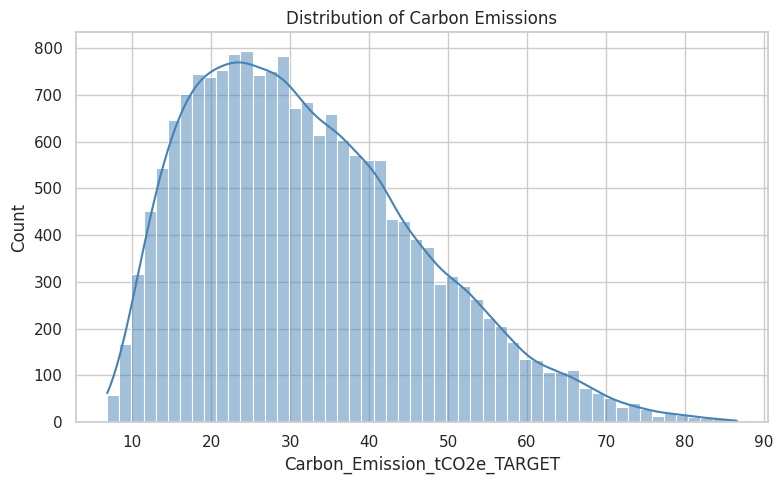

In [27]:
skewness_value = df_clean[target_col].skew()
kurtosis_value = df_clean[target_col].kurtosis()

print('Skewness:', round(skewness_value, 4))
print('Kurtosis:', round(kurtosis_value, 4))

if abs(skewness_value) < 0.5:
    normality_note = 'approximately symmetric'
elif skewness_value > 0:
    normality_note = 'right-skewed'
else:
    normality_note = 'left-skewed'

print('Distribution interpretation:', normality_note)

plt.figure(figsize=(8, 5))
sns.histplot(df_clean[target_col], kde=True, color='steelblue')
plt.title('Distribution of Carbon Emissions')
plt.tight_layout()
plt.show()

In [28]:
top_correlations = correlation_with_target.drop(target_col).head(10)
top_correlations

NonRenewable_Energy_Consumption_kWh    0.937198
Carbon_Tax_USD                         0.855654
Total_Energy_Consumption_kWh           0.777758
Energy_Cost_USD                        0.626154
Expected_Renewable_Share_Percent      -0.476811
Renewable_Energy_Consumption_kWh       0.070036
Expected_Carbon_Reduction_Percent      0.010295
Raw_Material_Usage_kg                  0.009820
Social_Impact_Score                    0.007216
Production_Output_Units                0.006059
Name: Carbon_Emission_tCO2e_TARGET, dtype: float64

In [29]:
first_30 = daily[target_col].iloc[:30].mean()
last_30 = daily[target_col].iloc[-30:].mean()
trend_change_percent = ((last_30 - first_30) / first_30) * 100

monthly_avg = daily[target_col].resample('ME').mean()
seasonal_range = monthly_avg.max() - monthly_avg.min()

answers = {
    'Q1: Highest variability source': variability.index[0],
    'Q2: Are emissions normally distributed?': f'Not perfectly normal. The distribution is {normality_note} with skewness {skewness_value:.3f}.',
    'Q3: Strongest correlated variables with emissions': top_correlations.head(5).to_dict(),
    'Q4: Emissions trend': f'Average emissions changed by {trend_change_percent:.2f}% from the first 30 days to the last 30 days.',
    'Q5: Seasonal patterns': f'Monthly average emissions range is {seasonal_range:.3f} tCO2e, indicating weak seasonal variation in this dataset.'
}

for question, answer in answers.items():
    print(question)
    print(answer)
    print('-' * 80)

Q1: Highest variability source
Renewable_Energy_Consumption_kWh
--------------------------------------------------------------------------------
Q2: Are emissions normally distributed?
Not perfectly normal. The distribution is right-skewed with skewness 0.666.
--------------------------------------------------------------------------------
Q3: Strongest correlated variables with emissions
{'NonRenewable_Energy_Consumption_kWh': 0.9371984885826435, 'Carbon_Tax_USD': 0.8556542539353357, 'Total_Energy_Consumption_kWh': 0.7777583830025389, 'Energy_Cost_USD': 0.6261544415864068, 'Expected_Renewable_Share_Percent': -0.4768106690130693}
--------------------------------------------------------------------------------
Q4: Emissions trend
Average emissions changed by 1.51% from the first 30 days to the last 30 days.
--------------------------------------------------------------------------------
Q5: Seasonal patterns
Monthly average emissions range is 1.016 tCO2e, indicating weak seasonal variat

## Final Notes

The analysis shows that carbon emissions are mainly connected with non-renewable energy consumption, carbon tax, and total energy consumption. The uploaded dataset does not include a temperature column, so the temperature-related plots are handled with conditional code.

In [30]:
df_clean.to_csv('cleaned_carbon_emission_dataset.csv', index=False)
print('Cleaned dataset saved as cleaned_carbon_emission_dataset.csv')

Cleaned dataset saved as cleaned_carbon_emission_dataset.csv
